# nb22 — Pure-gNFW tSZ power spectrum at best-fit mass bias B

Fix the cosmology to the FLAMINGO **D3A** truth, take the **best-fit hydrostatic
mass bias B** from the `mcmc_pureGNFW_fitB` chains at each SNR cut q, and compare
the **hmfast** theoretical Arnaud-2010 gNFW tSZ power spectrum prediction
against the observed binned data points D_ell^yy.

The pressure shape (P0, c500, alpha, beta, gamma) is the bare Arnaud (2010)
gNFW, sigma_lnY = 0; only B varies between cuts. This reproduces the exact
`HMFastTSZIterGNFW` cobaya theory: the q-selection (SR completeness) grid is
built once at the seed cosmology, the C_ell is evaluated at D3A.


In [1]:
import os, sys
os.environ["HMFAST_COBAYA_USE_GPU"] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

COBAYA_DIR = "/scratch/scratch-lxu/flamingo_data_analysis/flamingo_l2p8_lc0/catalogue_finding/cobaya_inference"
sys.path.insert(0, os.path.join(COBAYA_DIR, "code", "theory"))

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from getdist import loadMCSamples

# Importing the theory module performs the one-time JAX/GPU setup (float64) and
# exposes the shared fiducial seed cosmology, ell-binning and A_s reference used
# by the HMFastTSZIterGNFW cobaya theory.
from hmfast_tsz_iter_cprofile import (
    _FID, _bin_to_18, _ELL_MIN, _ELL_MAX, _A_S_REF, _LN1E10_A_S_REF)
from hmfast.cosmology import Cosmology
from hmfast.halos import HaloModel
from hmfast.halos.mass_definition import MassDefinition
from hmfast.halos.profiles import GNFWPressureProfile
from hmfast.tracers import tSZTracer
from hmfast.tracers.tsz_completeness import (
    build_snr_grid, conditional_An_undetected, load_sigma_y0_curve)

## Configuration

D3A cosmology (fixed), Arnaud-2010 gNFW shape (fixed), and the per-cut
q-selection (iterative-SR completeness) parameters, taken verbatim from the
`cobaya_yy_iter_<tag>_pureGNFW_fitB_mcmc.yaml` configs.

In [2]:
# FLAMINGO D3A truth cosmology (fixed in the fit-B chains)
D3A = dict(sigma8=0.811, omega_cdm=0.118729, omega_b=0.022539,
           H0=68.1, n_s=0.967, tau_reio=0.0544)

# Arnaud (2010) gNFW pressure shape (fixed)
ARN = dict(P0=8.403, c500=1.177, alpha=1.051, beta=5.4905, gamma=0.3081)

# Per-cut: q_cat threshold, iterative-SR (a_sz_sr, alpha_sr, b_sr), data files.
CUTS = [
    dict(tag="fullsky", label="Full sky", q_cat=1.0e9,
         a_sz_sr=-4.277981997317676, alpha_sr=0.952057528307069, b_sr=1.25,
         data="Dl_yy_obscat_fullsky_binned_18.txt",
         cov="cov_full_obscat_fullsky_Dl_yy_binned_18.npy",
         chain="yy_iter_fullsky_pureGNFW_fitB"),
    dict(tag="qgt5", label="q > 5", q_cat=5.0,
         a_sz_sr=-4.277981997317676, alpha_sr=0.952057528307069, b_sr=1.25,
         data="Dl_yy_itercat_qgt5_binned_18.txt",
         cov="cov_full_itercat_qgt5_Dl_yy_binned_18.npy",
         chain="yy_iter_qgt5_pureGNFW_fitB"),
    dict(tag="qgt10", label="q > 10", q_cat=10.0,
         a_sz_sr=-4.270843927746104, alpha_sr=0.9444223458089253, b_sr=1.25,
         data="Dl_yy_itercat_qgt10_binned_18.txt",
         cov="cov_full_itercat_qgt10_Dl_yy_binned_18.npy",
         chain="yy_iter_qgt10_pureGNFW_fitB"),
    dict(tag="qgt20", label="q > 20", q_cat=20.0,
         a_sz_sr=-4.251361373150767, alpha_sr=0.9236653041902941, b_sr=1.25,
         data="Dl_yy_itercat_qgt20_binned_18.txt",
         cov="cov_full_itercat_qgt20_Dl_yy_binned_18.npy",
         chain="yy_iter_qgt20_pureGNFW_fitB"),
    dict(tag="qgt50", label="q > 50", q_cat=50.0,
         a_sz_sr=-4.212273738811673, alpha_sr=0.8765101646932605, b_sr=1.25,
         data="Dl_yy_itercat_qgt50_binned_18.txt",
         cov="cov_full_itercat_qgt50_Dl_yy_binned_18.npy",
         chain="yy_iter_qgt50_pureGNFW_fitB"),
]
DATA_DIR  = os.path.join(COBAYA_DIR, "data")
CHAIN_DIR = os.path.join(COBAYA_DIR, "chains", "mcmc_pureGNFW_fitB")

## Best-fit B at each q

Best fit = maximum-a-posteriori sample (minimum of -log posterior). With a flat
prior on B and fixed cosmology this equals the maximum-likelihood B.

In [3]:
bestfit_B = {}
for cut in CUTS:
    s = loadMCSamples(os.path.join(CHAIN_DIR, cut["chain"]),
                      settings={"ignore_rows": 0.3})
    B = np.asarray(s.getParams().B)
    i = int(np.argmin(s.loglikes))          # MAP sample
    bestfit_B[cut["tag"]] = float(B[i])
    print(f"{cut['label']:9s}  B_bestfit={B[i]:.4f}  (mean {s.mean('B'):.4f} "
          f"+/- {s.std('B'):.4f})")

Full sky   B_bestfit=1.1093  (mean 1.1101 +/- 0.0060)
q > 5      B_bestfit=1.0818  (mean 1.0817 +/- 0.0015)
q > 10     B_bestfit=1.1068  (mean 1.1069 +/- 0.0019)
q > 20     B_bestfit=1.1113  (mean 1.1108 +/- 0.0028)
q > 50     B_bestfit=1.1155  (mean 1.1152 +/- 0.0036)


## hmfast theory setup

Seed cosmology / halo model / gNFW profile / tSZ tracer, plus the SNR
completeness coefficients. The mass and redshift grids and internal ell grid
match the cobaya theory (n_mass=64, n_z=96, n_ell_internal=50).

In [4]:
m = jnp.geomspace(1e10, 10**15.5, 64)
z = jnp.geomspace(0.005, 3.0, 96)
ell_int = jnp.geomspace(float(_ELL_MIN[0]), float(_ELL_MAX[-1]), 50)
ell_np = np.asarray(ell_int)

cosmo_seed = Cosmology(emulator_set="lcdm:v1")
hm_seed = HaloModel(cosmology=cosmo_seed.update(**_FID),
                    mass_definition=MassDefinition(500, "critical"),
                    convert_masses=True)
prof_seed = GNFWPressureProfile(B=1.4, **ARN)
tsz_seed = tSZTracer(profile=prof_seed)
coeff, _ = load_sigma_y0_curve()

# sigma8 -> ln(1e10 A_s) at D3A (replicates HMFastTSZIterGNFW._sigma8_to_lnA_s)
_c = cosmo_seed.update(H0=D3A["H0"], omega_cdm=D3A["omega_cdm"],
                       omega_b=D3A["omega_b"], ln1e10A_s=_LN1E10_A_S_REF,
                       n_s=D3A["n_s"], tau_reio=D3A["tau_reio"])
_s8ref = float(np.asarray(_c.sigma8(0.0)))
ln1e10As_D3A = float(np.log(1e10 * _A_S_REF * (D3A["sigma8"] / _s8ref) ** 2))
cosmo_D3A = cosmo_seed.update(H0=D3A["H0"], omega_cdm=D3A["omega_cdm"],
                              omega_b=D3A["omega_b"], ln1e10A_s=ln1e10As_D3A,
                              n_s=D3A["n_s"], tau_reio=D3A["tau_reio"])
hm_D3A = hm_seed.update(cosmology=cosmo_D3A)
print(f"D3A sigma8 check: target=0.811  emulator(seed A_s)={_s8ref:.4f}  ln1e10A_s={ln1e10As_D3A:.4f}")

D3A sigma8 check: target=0.811  emulator(seed A_s)=0.8069  ln1e10A_s=3.0545


## Theory prediction per q

For each cut: build the q-selection mask grid at the seed cosmology (as the
cobaya theory does), then evaluate the masked 1-halo + 2-halo D_ell^yy at D3A
with the best-fit B, binned to the 18 data bins.

In [5]:
def predict_Dl(cut, B):
    snr = build_snr_grid(hm_seed, m, z, cut["a_sz_sr"], cut["alpha_sr"],
                         cut["b_sr"], coeff=coeff)
    prof = prof_seed.update(B=B, **ARN)
    tsz = tsz_seed.update(profile=prof)
    mask1 = conditional_An_undetected(snr, sigma_lnY=0.0, q_cat=cut["q_cat"], n_power=2)
    mask2 = conditional_An_undetected(snr, sigma_lnY=0.0, q_cat=cut["q_cat"], n_power=1)
    cl1 = hm_D3A.cl_1h_masked(tsz, None, ell_int, m, z, mask1)
    cl2 = hm_D3A.cl_2h_masked(tsz, None, ell_int, m, z, mask2)
    Dl1 = _bin_to_18(ell_np, np.asarray(cl1))
    Dl2 = _bin_to_18(ell_np, np.asarray(cl2))
    return np.asarray(Dl1), np.asarray(Dl2)

results = {}
for cut in CUTS:
    B = bestfit_B[cut["tag"]]
    Dl1, Dl2 = predict_Dl(cut, B)
    D = np.loadtxt(os.path.join(DATA_DIR, cut["data"]))
    cov = np.load(os.path.join(DATA_DIR, cut["cov"]))
    ell, Dl_obs = D[:, 0], D[:, 1]
    err = np.sqrt(np.diag(cov))
    Dl_th = Dl1 + Dl2
    resid = Dl_obs - Dl_th
    chi2 = float(resid @ np.linalg.inv(cov) @ resid)
    results[cut["tag"]] = dict(ell=ell, Dl_obs=Dl_obs, err=err, Dl_th=Dl_th,
                               Dl_1h=Dl1, Dl_2h=Dl2, chi2=chi2, B=B)
    print(f"{cut['label']:9s}  B={B:.4f}  chi2={chi2:8.1f} / {len(ell)} bins")

Full sky   B=1.1093  chi2=    18.4 / 18 bins
q > 5      B=1.0818  chi2=  2396.5 / 18 bins
q > 10     B=1.1068  chi2=  1110.9 / 18 bins
q > 20     B=1.1113  chi2=   695.0 / 18 bins
q > 50     B=1.1155  chi2=   109.5 / 18 bins


## Goodness of fit

For each SNR cut: chi^2 against the full binned covariance, the number of
degrees of freedom (18 bins, B held at its best-fit value so no parameter is
subtracted here), the reduced chi^2, and the probability-to-exceed (PTE).

In [6]:
from scipy.stats import chi2 as _chi2dist

ndof = 18  # bins; B held at its best-fit value
print(f"{'cut':9s} {'B':>7s} {'chi2':>10s} {'dof':>4s} {'chi2/dof':>9s} {'PTE':>10s}")
print("-" * 56)
for cut in CUTS:
    r = results[cut["tag"]]
    pte = float(_chi2dist.sf(r["chi2"], ndof))
    print(f"{cut['label']:9s} {r['B']:7.4f} {r['chi2']:10.1f} {ndof:4d} "
          f"{r['chi2']/ndof:9.2f} {pte:10.2e}")

cut             B       chi2  dof  chi2/dof        PTE
--------------------------------------------------------
Full sky   1.1093       18.4   18      1.02   4.28e-01
q > 5      1.0818     2396.5   18    133.14   0.00e+00
q > 10     1.1068     1110.9   18     61.71  1.38e-224
q > 20     1.1113      695.0   18     38.61  6.54e-136
q > 50     1.1155      109.5   18      6.08   3.86e-15


## Figure: theory vs data points

saved -> /scratch/scratch-lxu/flamingo_repo/figures/nb22_pureGNFW_bestfitB_tsz_ps


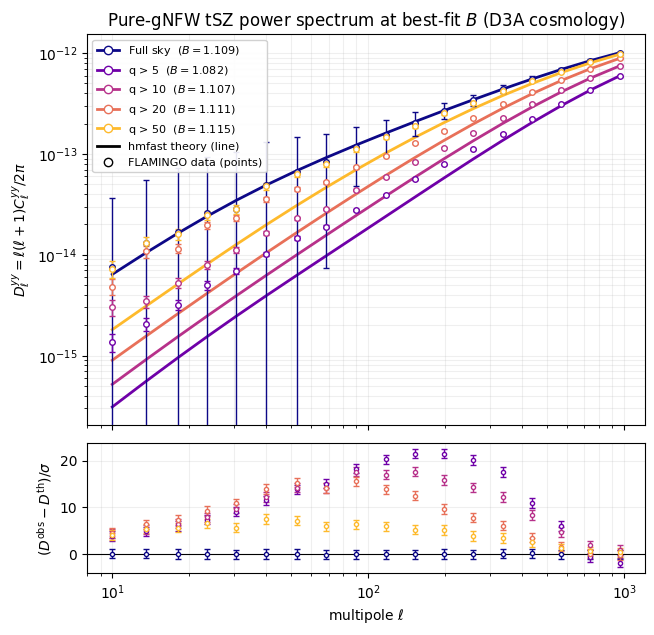

In [7]:
from matplotlib.lines import Line2D

colors = plt.cm.plasma(np.linspace(0.0, 0.85, len(CUTS)))
fig, (ax, axr) = plt.subplots(2, 1, figsize=(7.2, 7.0), sharex=True,
                              gridspec_kw=dict(height_ratios=[3, 1], hspace=0.07))

for cut, col in zip(CUTS, colors):
    r = results[cut["tag"]]
    ax.plot(r["ell"], r["Dl_th"], "-", color=col, lw=2, zorder=3)
    ax.errorbar(r["ell"], r["Dl_obs"], yerr=r["err"], fmt="o", color=col,
                ms=4, capsize=2, elinewidth=1, mfc="white", zorder=4)
    axr.errorbar(r["ell"], (r["Dl_obs"] - r["Dl_th"]) / r["err"], yerr=1.0,
                 fmt="o", color=col, ms=3, capsize=2, elinewidth=1, mfc="white")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_ylabel(r"$D_\ell^{yy} = \ell(\ell+1)C_\ell^{yy}/2\pi$")
ax.set_title("Pure-gNFW tSZ power spectrum at best-fit $B$ (D3A cosmology)")
ax.grid(True, which="both", alpha=0.2)

handles = [Line2D([0], [0], color=c, marker="o", mfc="white", lw=2,
                  label=f"{cut['label']}  ($B={results[cut['tag']]['B']:.3f}$)")
           for cut, c in zip(CUTS, colors)]
handles.append(Line2D([0], [0], color="k", lw=2, label="hmfast theory (line)"))
handles.append(Line2D([0], [0], color="k", marker="o", mfc="white", ls="none",
                      label="FLAMINGO data (points)"))
ax.legend(handles=handles, fontsize=8, loc="upper left", framealpha=0.9)

axr.axhline(0, color="k", lw=0.8)
axr.set_ylabel(r"$(D^{\rm obs}-D^{\rm th})/\sigma$")
axr.set_xlabel(r"multipole $\ell$")
axr.grid(True, which="both", alpha=0.2)

OUTDIR = "/scratch/scratch-lxu/flamingo_repo/figures/nb22_pureGNFW_bestfitB_tsz_ps"
os.makedirs(OUTDIR, exist_ok=True)
fig.savefig(os.path.join(OUTDIR, "nb22_pureGNFW_bestfitB_tsz_ps.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(OUTDIR, "nb22_pureGNFW_bestfitB_tsz_ps.pdf"), bbox_inches="tight")
print("saved ->", OUTDIR)
plt.show()

## Notes

The error bars are the square root of the diagonal of the **full** binned
covariance (`cov_full_*`). These are tight, so although the best-fit B captures
the overall amplitude and shape, the reduced chi^2 is large: the residual panel
shows the data sit several sigma from the fixed-shape gNFW prediction at some
multipoles. This is consistent with the -log posterior values stored in the
chains. The best-fit B is nearly constant across cuts (b = 1 - 1/B ~ 0.10),
i.e. roughly q-independent.